# A bifurcation diagram: how the long-term behavior changes

The logistic map,

$$x_{n+1}=\lambda x_n(1-x_n),$$

can approach a fixed point, a periodic cycle, or a chaotic trajectory as the growth parameter $\lambda$ changes. This notebook compresses thousands of separate simulations into one **bifurcation diagram**.

**How to read the plot:** choose a value on the horizontal axis and look vertically. The plotted populations are late values from a trajectory at that parameter. One height indicates a fixed point; two or four distinct heights indicate corresponding cycles; many heights can indicate complicated dynamics.

The central question is: **How does a stable, simple pattern lose stability as we change a parameter?**

In [3]:
from array import array
import matplotlib.pyplot as plt

## The update rule

`growthfunction` takes the current population and returns the next one. `par[0]` supplies $\lambda$. Every trajectory follows the same rule; only $\lambda$ changes across the parameter sweep. There is no random sampling in this calculation.

In [4]:
def growthfunction(x,par):
    return par[0]*x*(1.0-x)

## Choosing the sweep and discarding the transient

- `lambda_points = 5000` chooses the number of parameter values between `lambda_min` and just below `lambda_max`.
- `nstart = 1000` means that values with generation indices below 1000 are discarded.
- `npoints = 40` retains 40 late populations at each parameter, for 200,000 plotted points in total.

Discarding early values helps reveal long-term behavior rather than the approach to it. Near a stability boundary, convergence may be slow, so a fixed transient length is not a guarantee of complete settling.

**Implementation detail for experiments:** the simulation below sets `population[0] = 0.3` directly. Changing the `xstart` variable in this settings cell alone will not change the starting population; the assignment inside the loop must also be changed.

In [11]:
nstart = 1000
npoints = 40
lambda_points = 50000
lambda_min = 0.90
lambda_max = 3.999
xstart = 0.3

n = nstart+npoints
nvalues = npoints
lambda_n = lambda_points

## Building the diagram, one vertical slice at a time

The outer loop selects a new $\lambda$ and resets the population to 0.3. The inner loop iterates the map. Only values with `i >= nstart` are appended to `myvalues`, together with their matching parameter values in `lambdavalues`.

Each vertical slice therefore comes from **one trajectory at one fixed parameter**, not from different randomly chosen initial populations. For a settled periodic orbit, many of the 40 retained points overlap. For a long-period or chaotic orbit, 40 values give only a limited sample.

In [12]:
population = array('d')
year = array('d')
lmbda = array('d')
lambda_now =array('d')
xvalue = array('d')
myvalues = array('d')
lambdavalues = array('d')


for i in range(0,n):
    year.append(0)
    population.append(0)

lambda_now.append(0)

for j in range(0,lambda_n):
    lmbda.append(lambda_min + (lambda_max-lambda_min)*j/lambda_n)
    year[0] = 0.0
    population[0] = 0.3
    lambda_now[0] = lmbda[j]
    
    for i in range(1,n):
        year[i]=i
        x = population[i-1]
        population[i]=growthfunction(x,lambda_now)
        if (i>=nstart):
            #print(j,i,population[i],lambda_now[0])
            myvalues.append(population[i])
            lambdavalues.append(lambda_now[0])

## Reading the branches

For $0<\lambda<1$, trajectories starting inside $(0,1)$ approach extinction. For $1<\lambda<3$, they approach the nonzero fixed point

$$x^*=1-\frac{1}{\lambda}.$$

Its stability multiplier is $f'(x^*)=2-\lambda$. At $\lambda=3$ it reaches $-1$, and the fixed point gives way to a two-cycle. Further increases produce a sequence of period doublings: two branches become four, then eight, and so on.

The plot's label **“Equilibrium Population”** should be read here as **“late-iteration population.”** Only a single stationary branch is an equilibrium; a cycle or chaotic trajectory keeps changing with generation.

Markers are drawn without connecting lines because neighboring points may belong to different phases of a cycle or different parameter values.

(0.9, 4.0)

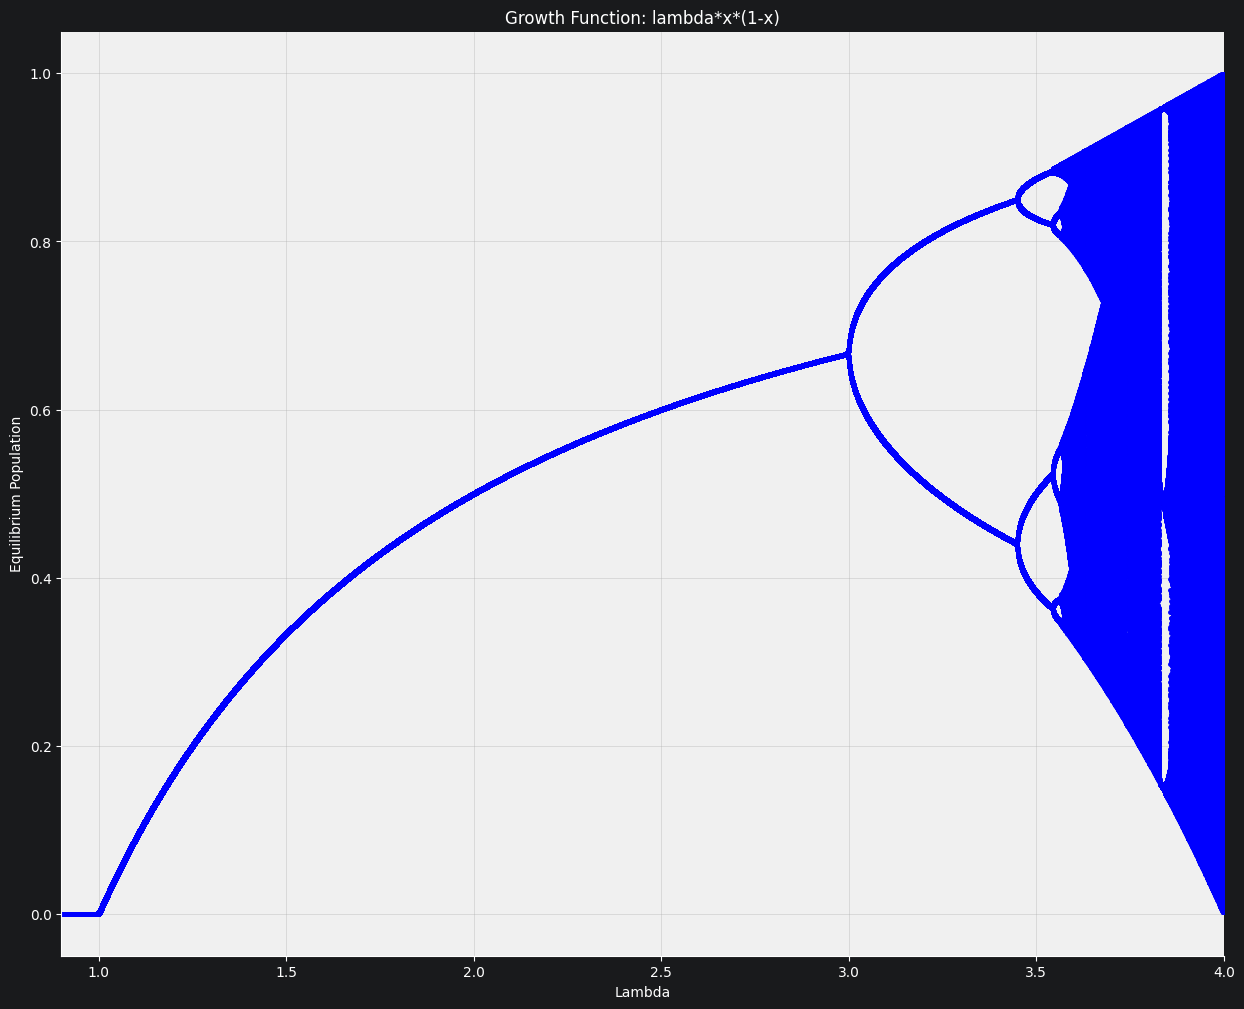

In [16]:
# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 12))

# Set the grid lines
ax.grid(True)

# Set the background color
ax.set_facecolor('#F0F0F0')

# Set the border properties
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the canvas size
ax.set_title('Chaos Example')

# Set the line and marker properties
line_color = 'b'
line_width = 0
marker_color = 'b'
marker_style = '.'
marker_size = 5

# Create the plot
plt.plot(lambdavalues, myvalues, color=line_color, linewidth=line_width,
         marker=marker_style, markersize=marker_size, markerfacecolor=marker_color)

# Set the plot title and axis labels
plt.title("Growth Function: lambda*x*(1-x)")
plt.xlabel("Lambda")
plt.ylabel("Equilibrium Population")
plt.xlim(0.900,4.000)

## What the diagram shows—and what it cannot establish alone

Look for the single branch, its splitting into multiple branches, dense bands, and **periodic windows** within otherwise complicated regions. Increasing $\lambda$ does not simply make the motion progressively more chaotic at every step.

A dense collection of points is suggestive, but does not by itself prove chaos: a long-period cycle or a lingering transient can also give many distinct values. Sensitivity to nearby initial conditions provides complementary evidence.

**Discussion and experiments:**

- Locate $\lambda=1.3$, 2.5, 3.2, 3.5, and 3.99 and relate their vertical slices to the first notebook's time series.
- Increase `nstart` to check whether apparent features are transient effects.
- Increase `npoints` to sample complicated trajectories more fully.
- Narrow `lambda_min` and `lambda_max` to inspect a branch splitting or periodic window. Also adjust `plt.xlim(...)`, which is currently fixed independently of those settings.

A bifurcation diagram shows which populations are visited. The histogram notebook asks a different question: **How often are different populations visited?**